# Limited Diffusion

Longxiao, LMU

python version: 3.10.19

This notebook is used to illustrate the result of a different type of diffusion model, where the dispersal of articles (individuals) is limited by a maxima. 

In random diffusion, the diffusion rate is in a linear relation with local flux.
$$
    \partial_{t} u = \nabla^{2}_{x} u
$$
This lead to the result that articles in this model is actually probable to dispersal infinity far in any time interval, which caused a unlimited speed. To limit it, we could introduce a nonlinear function of local density as the diffusion rate, makes the temporal diffusion:
$$
    \partial_t u = \nabla\left( D(u)\nabla u \right)
$$
where
$$
    D(u) = \frac{u^b}{(1-u)^b}
$$.

This might limit the dispersal of articles because when $u = 0$, the diffusion rate is also $0$.

> Okubo, A. and Chiang, H. C. (1974). An analysis of the kinematics of swarming of Anarete pritchardi kim (Diptera: Cecidomyiidae). Researches on Population Ecology, 16(1):1–42.
> Namba, T. (1980). Density-dependent dispersal and spatial distribution of a population. Journal of Theoretical Biology, 86(2):351–363.

Here we simulate this limited diffusion which started from a central distribution.

In [1]:
# import library
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Parameters
L = 2.0          # Space length
Nx = 200         # number of spatial grids
dx = 2 * L / Nx

T = 5.1          # Time 
dt = 1e-6        # temporal step length
Nt = int(T / dt)

b = 2.0           # diffusion parameter 

# time point draw
plot_times = [0.0, 0.005, 0.05, 0.5, 5]

# generate spatial grids
x = np.linspace(-L, L, Nx)

# Initial state
# using a very narrow Gaussian distribution instead of delta function
sigma = 0.01
u = np.exp(-x**2 / (2 * sigma**2))
u /= np.sum(u) * dx 

# avoid divergence
u = np.clip(u, 1e-12, 1-1e-12)

# function: diffusion rate
def D(u):
    eps = 1e-10
    u = np.clip(u, eps, 1 - 1e-6)
    return (u**b) / ((1 - u)**b)

We use Explicit Finite Difference Method to simulate the PDE system.
$$
    \partial_t u = \nabla\left( D(u)\nabla u \right)
$$
The full form is
$$
    \frac{\partial u}{\partial t} = \frac{\partial}{\partial x} \left(D(u)\cdot \frac{\partial  u}{\partial x}\right)
$$

We discretized time and space with $\Delta t$ and $\Delta x$, then
$$
    \frac{\partial u}{\partial t} \approx \frac{u_{i,k+1} - u_{i,k}}{\Delta t}
$$
and
$$
    \frac{\partial u}{\partial x} \approx \frac{u_{i+1,k} - u_{i,k}}{\Delta x}
$$
Thus, the flux of diffusion is
$$
    \text{flux}_{i,k} = D(u_{i,k}) \cdot \frac{u_{i+1,k} - u_{i,k}}{\Delta x}
$$
And
$$
    \frac{\partial}{\partial x} \left(D(u)\cdot \frac{\partial  u}{\partial x}\right)
    \approx \frac{\text{flux}_{i+1,k} - \text{flux}_{i,k}}{\Delta x}
$$

As a result, we could calculate the next time step by
$$
    u_{i,k+1} = u_{i,k} + \Delta t \cdot \left( \frac{\text{flux}_{i+1,k} - \text{flux}_{i,k}}{\Delta x} \right)
$$

In [ ]:
#==========================
# Start simulation
nonlinear_result = {}
current_time = 0.0

# Explicit Finite Difference Method
for n in range(Nt):

    u_mid_right = 0.5 * (u[1:] + u[:-1])
    D_mid = D(u_mid_right)

    flux = D_mid * (u[1:] - u[:-1]) / dx

    dudt = np.zeros_like(u)
    dudt[1:-1] = (flux[1:] - flux[:-1]) / dx

    # Neumann boundary condition
    dudt[0] = 0
    dudt[-1] = 0

    # update
    u += dt * dudt
    #u = np.clip(u, 1e-12, 0.999)
    current_time += dt

    # save time points
    for pt in plot_times:
        if pt not in nonlinear_result and current_time >= pt:
            nonlinear_result[pt] = u.copy()

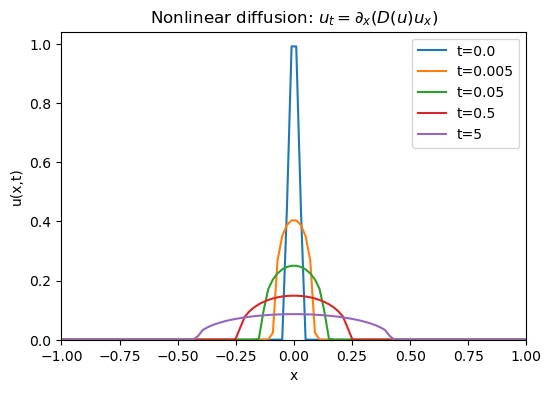

In [ ]:
# draw
plt.figure(figsize=(6,4))

for pt in plot_times:
    plt.plot(x, nonlinear_result[pt], label=f"t={pt}")

plt.xlim(-1, 1)
plt.ylim(bottom=0)

plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title(r"Nonlinear diffusion: $u_t=\partial_x(D(u)u_x)$")

plt.legend()
#plt.grid(True)
plt.show()

The result of limited diffusion shows a steep end at both side which is the maximum dispersal of individuals.

Then we apply this model into reaction-diffusion model. For example, we use limited diffusion in Fisher-KPP model
$$
\partial_t u = \nabla\left( D(u) \nabla u \right) + u(1-u)
$$

In [12]:
# Basic parameters
# space
L = 5.0
Nx = 500
dx = 2 * L / Nx
x = np.linspace(-L, L, Nx)
# time
T = 10.1
dt = 1e-5
Nt = int(T / dt)
# diffusion parameter
b = 2.0

# draw time point
plot_times = [0, 1, 2, 4, 6, 8, 10]

# Initial state
# species invading the space in a initial distribution of tanh
# which centered at x = -0.9
# width control the central slope of the initial state
width = 0.01
u = (1 - np.tanh((x+0.9) / width))

u = np.clip(u, 1e-8, 1 - 1e-6)

# Diffusion rate
def D(u):
    eps = 1e-10
    u = np.clip(u, eps, 1 - 1e-8)
    return (u**b) / ((1 - u)**b)

In [13]:
nonlinear_df_result = {}
current_time = 0.0

for n in range(Nt):

    # Diffusion term
    u_mid = 0.5 * (u[1:] + u[:-1])
    D_mid = D(u_mid)
    flux = D_mid * (u[1:] - u[:-1]) / dx
    diffusion = np.zeros_like(u)
    diffusion[1:-1] = 0.01*(flux[1:] - flux[:-1]) / dx

    # Neumann boundary
    diffusion[0] = 0
    diffusion[-1] = 0

    # reaction term
    reaction = u * (1 - u)

    u += dt * (diffusion + reaction)

    u = np.clip(u, 0, 1 - 1e-8)

    current_time += dt

    for pt in plot_times:
        if pt not in nonlinear_df_result and current_time >= pt:
            nonlinear_df_result[pt] = u.copy()

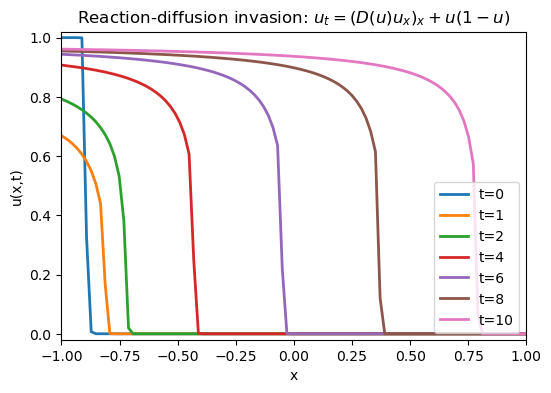

In [14]:
# ==================================
# draw nonlinear-reaction-diffusion
plt.figure(figsize=(6,4))

for pt in plot_times:
    plt.plot(x, nonlinear_df_result[pt], lw=2, label=f"t={pt}")

plt.xlabel("x")
plt.ylabel("u(x,t)")

plt.title(
    r"Reaction-diffusion invasion: "
    r"$u_t=(D(u)u_x)_x+u(1-u)$"
)

plt.xlim(-1, 1)
plt.ylim(-0.02, 1.02)

#plt.grid(True)
plt.legend()

plt.show()

There is a similar traveling wave as normal reaction-diffusion model, but with a hard end.